**Вайцеховский Егор, 5130901/20102**


### *Упражнение 10.1.*

В разделе «Акустическая характеристика» методических материалов умножение ДПФ сигнала на передаточную функцию соответствует круговой свёртке, но в предположении периодичности сигнала. В результате на выходе, в начале фрагмента,слышна лишняя нота. Такого эффекта можно избежать, добавив в конец сигнала перед ДПФ определённое количество нулей.

Проверим наше предположение.

Сегмент звука выстрела из примера по данному уроку представлен ниже:


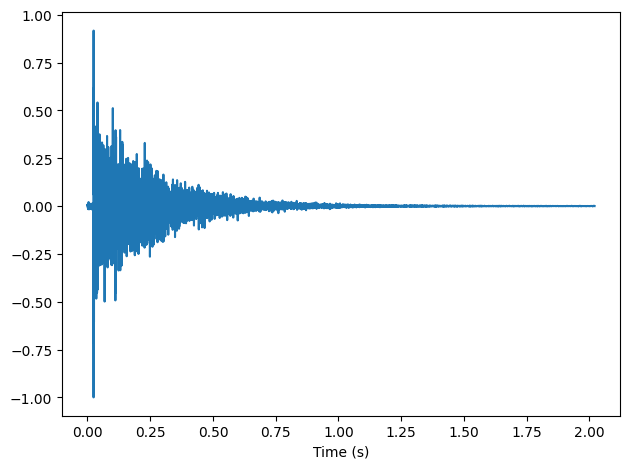

In [1]:
from thinkdsp import read_wave, decorate

# Open shot wave
response = read_wave('180960__kleeb__gunshot.wav')
start = 0.12
response = response.segment(start=start)
response.shift(-start)
response.normalize()
response.plot()
decorate(xlabel='Time (s)')
response.make_audio()

Теперь откроем и обрежем звук скрипки, чтобы сегменты были одинаковой длинны:

Отрывок представлен ниже:


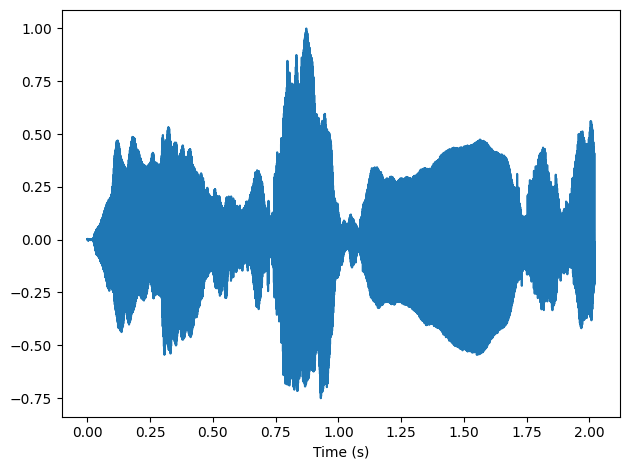

In [2]:
# Open violin wave
violin = read_wave('92002__jcveliz__violin-origional.wav')
start = 0.11
violin = violin.segment(start=start)
violin.shift(-start)
violin.truncate(len(response))
violin.normalize()
violin.plot()
decorate(xlabel='Time (s)')
violin.make_audio()

Воспроизведём эффект, про который говорится в методических материалах:


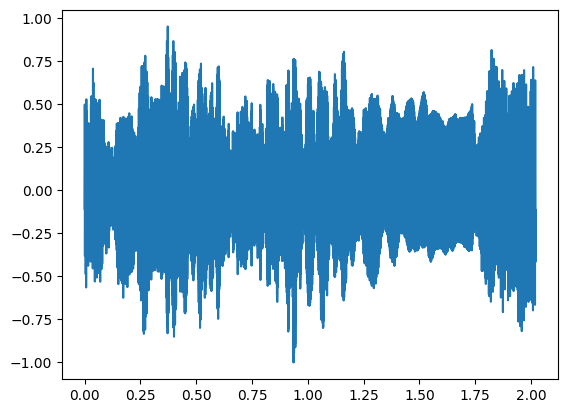

In [3]:
transfer = response.make_spectrum()
spectrum = violin.make_spectrum()
output = (spectrum * transfer).make_wave()
output.normalize()
output.plot()
output.make_audio()

В начале фрагмента мы слышим эффект «заворота». Попробуем его удалить, добавив в конец фрагментов нули, и повторим преобразование.


In [ ]:
response.zero_pad(len(response) * 2)
violin.zero_pad(len(violin) * 2)


Полученные графики:

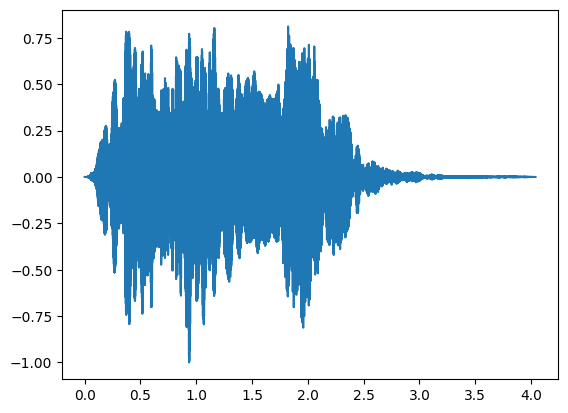

In [17]:
transfer = response.make_spectrum()
spectrum = violin.make_spectrum()
output = (spectrum * transfer).make_wave()
output.normalize()
output.plot()
output.make_audio()

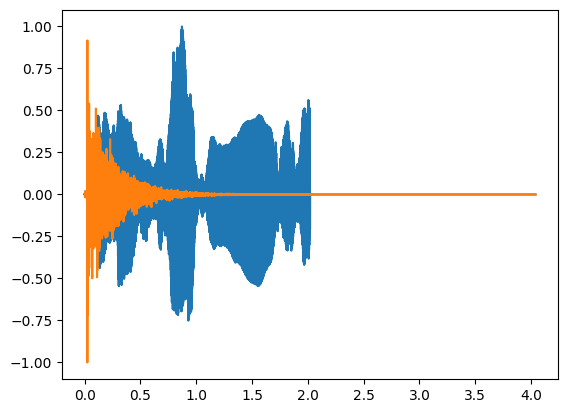

In [20]:
violin.plot()
response.plot()

На итоговом графике больше нет всплеска частот в самом начале, а значит, мы добились желаемого результата - мы избавились от  эффекта «заворота» на записи, что заметно при прослушивании.

### Упражнение 10.2

Промоделируем звучание выбранной записи в каком-то ином пространстве.

Откроем звук, описываюший наше "новое" пространство:


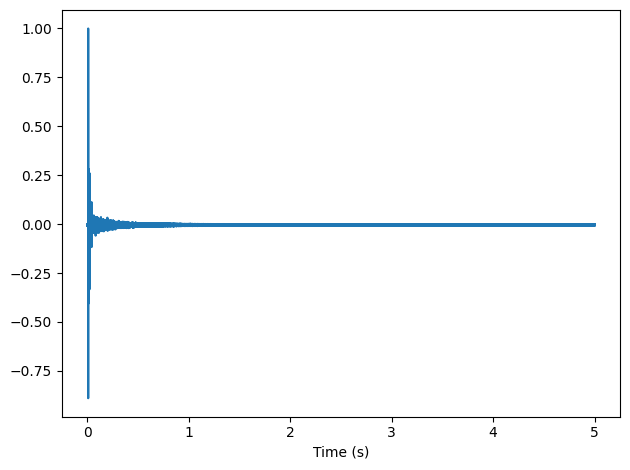

In [61]:
from thinkdsp import read_wave, decorate
# %%
response = read_wave('stalbans_a_mono.wav')
duration = 5
response = response.segment(duration=duration)
response.normalize()
response.plot()
decorate(xlabel='Time (s)')
response.make_audio()

Выбранный отрывок звучит как хлопок с эхом от него.

Его спектр выглядит так:


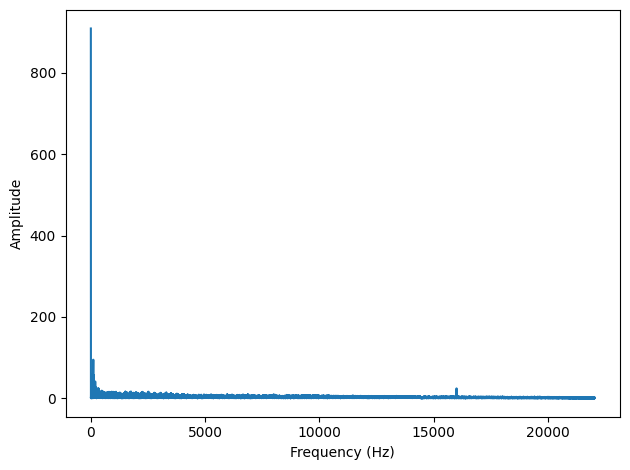

In [62]:
transfer = response.make_spectrum()
transfer.plot()
decorate(xlabel='Frequency (Hz)', ylabel='Amplitude')


Теперь откроем вторую запись - это звук гобоя, использованный ранее, и обрежем её под длину звука хлопка.

Получившийся отрезок выглядит так:


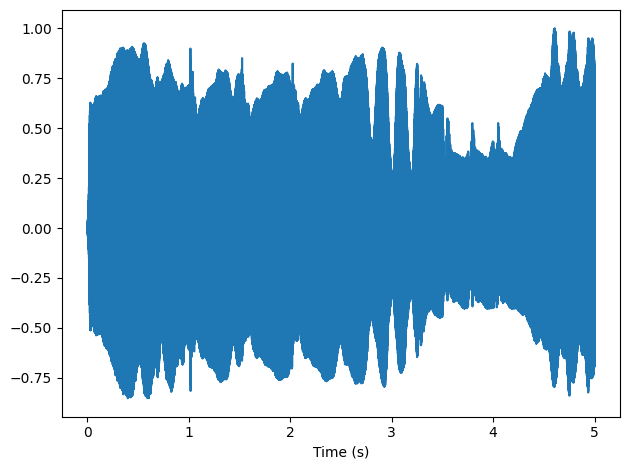

In [72]:
wave = read_wave('code_120994__thirsk__120-oboe.wav')
wave.truncate(len(response))
wave.normalize()
wave.plot()
decorate(xlabel='Time (s)')
wave.make_audio()


Спектр данного отрывка выглядит так:


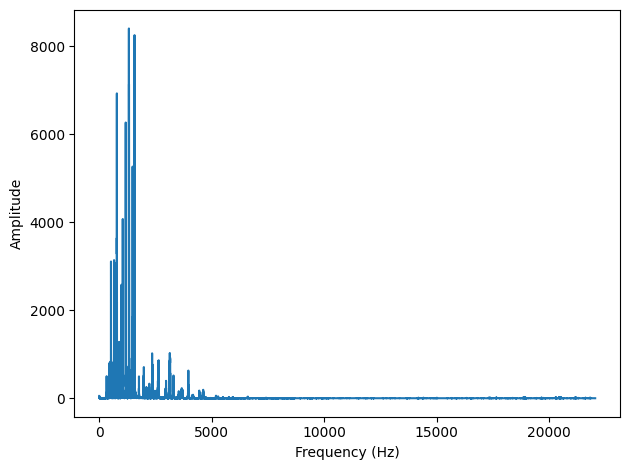

In [73]:
spectrum = wave.make_spectrum()
spectrum.plot()
decorate(xlabel='Frequency (Hz)', ylabel='Amplitude')

Сейчас мы можем получить звук барабанов в пространстве хлопка, применив умножение ДПФ.

Выведем результирующую волну:


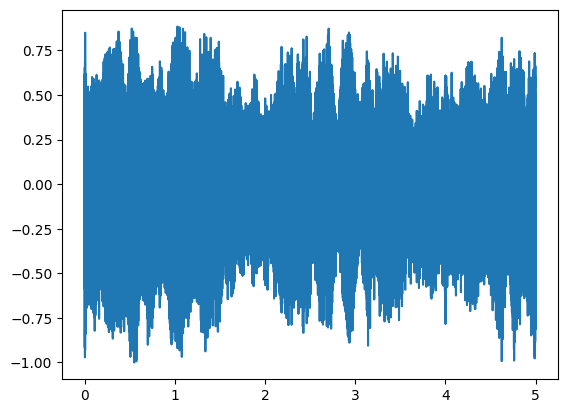

In [74]:
output = (spectrum * transfer).make_wave()
output.normalize()
output.plot()
output.make_audio()

В предыдущем пункте мы уже рассмотрели и удалили эффект «заворота». Сейчас наша запись тоже не совсем корректна из-за этого эффекта, но конкретно в этом примере его не слышно.

Следующий способ получить звучание записи гобоя в одном пространстве с хлопком – метод convolve:

Этот метод возвращает волну измененной длины, посмотрим на неё:


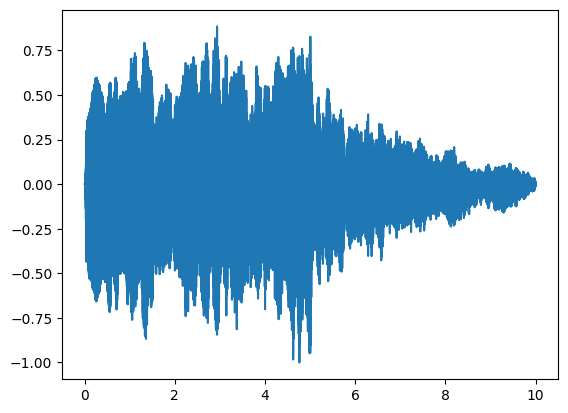

In [75]:
convolved2 = wave.convolve(response)
convolved2.normalize()
convolved2.plot()
convolved2.make_audio()

Сравнив результаты двух подходов, мы видим, что оба метода возвращают волну, соответствующую звуку в пространстве второго. Но всё же метод convolve был разработан специально для этой задачи, поэтому не подвержен эффекту «заворота» и не требует дополнительных манипуляций для получения корректного результата, хоть и работает заметно дольше.